<a href="https://colab.research.google.com/github/Ayan2582/Delineation-of-RTS/blob/common_preprocessing/Dataset_Setup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The **`rts_common.py`** file is a **shared, model-independent utility** for the GeoAI Arctic RTS experiments. Its purpose is to ensure that **Mask R-CNN, Cascade Mask R-CNN, and future models use consistent data handling**, so differences in results are primarily due to the models themselves.

### **1. LOADING + BAND AUDIT**

**Functions:** `load_chip`, `compute_band_stats`, `BandStats`

Loads the `.npz` RTS chips and handles **invalid/NaN/nodata values**. It also calculates and stores **per-band statistics** such as percentiles, mean, standard deviation, and NaN fraction.

### **2. PREPROCESSING**

**Class:** `Preprocessor`

Converts raw satellite data into **model-ready input**. It handles **NaN values, percentile-based clipping, standardization, and band selection**. For the current RGB models, it selects the **Red, Green, and Blue bands**.

### **3. CHIP DESCRIPTORS + CLUSTERING**

**Functions:** `chip_descriptor`, `Embedder`, `cluster`, `scan_k`, `cluster_montage`

Creates **numerical descriptions of chips** and groups similar chips together. This can be used to understand the dataset and investigate whether images have different characteristics.

### **4. SPLITS**

**Functions:** `cluster_split`, `random_split`, `random_folds`, `grouped_folds`, `save_splits`, `load_splits`

Creates and manages **train/validation splits**. the canonical 642 training / 114 validation split is generated and stored as splits/common_split.json so all models use the same data split.
### **5. SPLIT DIAGNOSTICS**

**Functions:** `adversarial_auc`, `split_similarity`

Checks whether the **training and validation sets are substantially different**. This helps identify possible distribution differences or problematic splits.

### **6. EVALUATION + FOLD EXPORT**

**Functions:** `subset_coco`, `write_fold_jsons`, `score_official`, `iou_metrics`

Handles **COCO annotations**, creates fold-specific data when required, and provides evaluation utilities such as **IoU and official segmentation scoring**.

### **7. CLI**

**Commands:** `audit`, `splits`, `single-split`, `materialize`, 'common-split'

Provides a **command-line interface** for running the utility functions directly. For example, `python rts_common.py audit ...` can calculate and save the **dataset statistics**.


In [1]:
from google.colab import drive
import os

# 1. Connect your Google Drive
drive.mount('/content/drive')

# 2. Go exactly to the folder shown in your screenshot
project_folder = '/content/drive/MyDrive/Mask r cnn'
os.chdir(project_folder)

print("I am now working inside:", os.getcwd())

Mounted at /content/drive
I am now working inside: /content/drive/MyDrive/Mask r cnn


In [2]:
%%writefile rts_common.py
from __future__ import annotations

import argparse
import json
import warnings
from dataclasses import asdict, dataclass
from pathlib import Path
import numpy as np

BAND_NAMES = ["red", "green", "blue", "ndvi", "relative_elevation",
              "shaded_relief", "nir", "ndwi"]
RGB = (0, 1, 2)
IMAGENET_MEAN_RGB = np.array([123.675, 116.28, 103.53], np.float32)  # Detectron2 default, RGB order

# 1. Loading + band audit
def load_chip(path, nodata=()):
    """Return the raw H x W x 8 float32 chip. inf and any `nodata` sentinel
values (e.g. -9999) become NaN; nothing else is changed."""
    with np.load(path) as z:
        arr = np.asarray(z["image"], dtype=np.float32).copy()
    arr[~np.isfinite(arr)] = np.nan
    for v in nodata:
        arr[arr == v] = np.nan
    return arr


@dataclass
class BandStats:
    """Per-band statistics used for clipping and standardization.
    Compute on TRAIN chips only, save to JSON, and commit the JSON."""
    names: list
    lo: list        # low clip value (percentile)
    hi: list        # high clip value (percentile)
    mean: list      # mean of clipped values
    std: list       # std of clipped values
    nan_frac: list
    vmin: list
    vmax: list
    n_chips: int

    def save(self, path):
        Path(path).write_text(json.dumps(asdict(self), indent=2))

    @classmethod
    def load(cls, path):
        return cls(**json.loads(Path(path).read_text()))

    def table(self):
        rows = [f"{'band':<20}{'min':>11}{'p_lo':>11}{'mean':>11}{'std':>11}{'p_hi':>11}{'max':>11}{'nan%':>8}"]
        for i, n in enumerate(self.names):
            rows.append(f"{n:<20}{self.vmin[i]:>11.3f}{self.lo[i]:>11.3f}{self.mean[i]:>11.3f}"
                        f"{self.std[i]:>11.3f}{self.hi[i]:>11.3f}{self.vmax[i]:>11.3f}"
                        f"{100 * self.nan_frac[i]:>8.2f}")
        return "\n".join(rows)


def compute_band_stats(paths, lo_pct=1.0, hi_pct=99.0, px_per_chip=5000,
                       seed=0, nodata=()):
    """NaN-aware per-band audit + robust stats over a list of chip paths."""
    rng = np.random.default_rng(seed)
    nb = len(BAND_NAMES)
    samples = [[] for _ in range(nb)]
    nan_cnt, total = np.zeros(nb), 0
    vmin, vmax = np.full(nb, np.inf), np.full(nb, -np.inf)
    for p in paths:
        flat = load_chip(p, nodata).reshape(-1, nb)
        fin = np.isfinite(flat)
        nan_cnt += (~fin).sum(0)
        total += flat.shape[0]
        for b in range(nb):
            v = flat[fin[:, b], b]
            if v.size == 0:
                continue
            vmin[b], vmax[b] = min(vmin[b], v.min()), max(vmax[b], v.max())
            if v.size > px_per_chip:
                v = rng.choice(v, px_per_chip, replace=False)
            samples[b].append(v)
    lo, hi, mean, std = [], [], [], []
    for b in range(nb):
        s = np.concatenate(samples[b]) if samples[b] else np.zeros(1, np.float32)
        l, h = np.percentile(s, [lo_pct, hi_pct])
        c = np.clip(s, l, h)
        lo.append(float(l)); hi.append(float(h))
        mean.append(float(c.mean())); std.append(float(max(c.std(), 1e-6)))
    return BandStats(BAND_NAMES, lo, hi, mean, std,
                     (nan_cnt / max(total, 1)).tolist(),
                     [float(x) for x in vmin], [float(x) for x in vmax], len(paths))


# 2. Preprocessing
class Preprocessor:
    """raw H x W x 8 chip (NaN = missing)  ->  float32 H x W x C model input.

    mode="global": clip each band to its [p_lo, p_hi] (from BandStats), then
                   z-score with the dataset mean/std. Keeps absolute
                   radiometry, which is what the pretrained-backbone
                   fine-tuning setup expects.
    mode="chip":   z-score each band with the chip's own mean/std (removes
                   per-chip brightness/season offsets; loses absolute values).

    Missing pixels are filled with 0 AFTER standardization (= the band mean),
    never before, so fill values do not distort the statistics. Set
    add_valid_mask=True to also give the network a 0/1 'pixel was valid'
    channel.

    mode="raw255": RGB only. Reproduces the existing PNG baseline exactly: raw 0-255
                   values, missing pixels = 0 (black, as prepare_png_dataset.py does),
                   minus the ImageNet mean. With bgr=True and PIXEL_MEAN=0 this is
                   bit-identical to what Detectron2's own DatasetMapper feeds the
                   network for those PNGs. Use it as the regression baseline.

    Detectron2 COCO checkpoints expect BGR input at "0-255 minus ImageNet mean"
    scale (std ~58). out_scale=58.395, bgr=True reproduces that convention from
    the z-scores, so the pretrained stem sees familiar magnitudes; then set
    cfg.MODEL.PIXEL_MEAN=[0]*C and PIXEL_STD=[1]*C (rts_detectron2.apply_common_cfg does).

    Same code path is used for train, val and test.
    """

    def __init__(self, stats: BandStats, bands=RGB, mode="global",
                 add_valid_mask=False, nodata=(), out_scale=1.0, bgr=False):
        assert mode in ("global", "chip", "raw255")
        self.stats, self.bands, self.mode = stats, tuple(bands), mode
        self.add_valid_mask, self.nodata = add_valid_mask, nodata
        self.out_scale, self.bgr = float(out_scale), bgr
        if bgr or mode == "raw255":
            assert self.bands[:3] == RGB, "bgr / raw255 need bands to start with (0, 1, 2)"
        if mode == "raw255":
            assert self.bands == RGB and not add_valid_mask, "raw255 is RGB-only"
        idx = list(self.bands)
        self._lo = np.asarray(stats.lo, np.float32)[idx]
        self._hi = np.asarray(stats.hi, np.float32)[idx]
        self._mu = np.asarray(stats.mean, np.float32)[idx]
        self._sd = np.asarray(stats.std, np.float32)[idx]

    @property
    def n_channels(self):
        return len(self.bands) + int(self.add_valid_mask)

    def __call__(self, raw):
        x = raw[..., list(self.bands)].astype(np.float32)
        valid = np.isfinite(x)
        if self.mode == "raw255":
            x = np.where(valid, np.clip(x, 0.0, 255.0), 0.0) - IMAGENET_MEAN_RGB
        else:
            if self.mode == "global":
                x = (np.clip(x, self._lo, self._hi) - self._mu) / self._sd
            else:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore", RuntimeWarning)
                    mu = np.nanmean(x, axis=(0, 1))
                    sd = np.nanstd(x, axis=(0, 1))
                x = np.clip((x - mu) / np.maximum(sd, 1e-6), -5.0, 5.0)
            x = np.where(valid, x, 0.0)
        x = x.astype(np.float32) * self.out_scale
        if self.bgr:
            x[..., [0, 2]] = x[..., [2, 0]]
        if self.add_valid_mask:
            x = np.concatenate([x, valid.all(-1, keepdims=True).astype(np.float32)], -1)
        return x

    def load(self, path):
        return self(load_chip(path, self.nodata))

# 3. Chip descriptors + clustering
def chip_descriptor(raw, stats: BandStats, n_bins=16):
    """Compact per-chip feature blocks (dict of 1-D arrays).
      hist    per-band histogram over the global [p_lo, p_hi] range, Hellinger (sqrt) scaled
      quant   per-band 5/25/50/75/95 percentiles, in global-std units
      nan     per-band NaN fraction
      texture mean gradient magnitude of the green band (sharpness / resolution cue)
      size    chip height, width
    """
    H, W, C = raw.shape
    flat = raw.reshape(-1, C)
    hist, quant, nanf = [], [], []
    for b in range(C):
        v = flat[np.isfinite(flat[:, b]), b]
        nanf.append(1.0 - v.size / flat.shape[0])
        if v.size == 0:
            hist.append(np.zeros(n_bins)); quant.append(np.zeros(5)); continue
        edges = np.linspace(stats.lo[b], stats.hi[b], n_bins + 1)
        h, _ = np.histogram(np.clip(v, stats.lo[b], stats.hi[b]), bins=edges)
        hist.append(np.sqrt(h / v.size))
        quant.append((np.percentile(v, [5, 25, 50, 75, 95]) - stats.mean[b]) / stats.std[b])
    g = np.nan_to_num(raw[..., 1], nan=float(stats.mean[1]))
    gy, gx = np.gradient(g)
    return {"hist": np.concatenate(hist), "quant": np.concatenate(quant),
            "nan": np.asarray(nanf), "texture": np.array([np.hypot(gx, gy).mean() / stats.std[1]]),
            "size": np.array([H, W], dtype=np.float64)}


def stack_descriptors(descs, blocks=("hist", "quant", "nan", "texture", "size")):
    return np.stack([np.concatenate([d[b] for b in blocks]) for d in descs]).astype(np.float64)


class Embedder:
    """StandardScaler + PCA, fitted on TRAIN descriptors, applied to anything."""

    def __init__(self, n_components=20):
        self.n_components = n_components

    def fit(self, X):
        from sklearn.decomposition import PCA
        from sklearn.preprocessing import StandardScaler
        self.scaler = StandardScaler().fit(X)
        Xs = self.scaler.transform(X)
        self.pca = PCA(n_components=min(self.n_components, Xs.shape[0] - 1, Xs.shape[1]),
                       random_state=0).fit(Xs)
        return self

    def transform(self, X):
        return self.pca.transform(self.scaler.transform(X))


def cluster(Z, k, method="kmeans", seed=0):
    """Returns (labels, centers). Centers are per-cluster means in Z space."""
    from sklearn.cluster import AgglomerativeClustering, KMeans
    if method == "kmeans":
        labels = KMeans(k, n_init=20, random_state=seed).fit_predict(Z)
    elif method == "agglo":
        labels = AgglomerativeClustering(k, linkage="ward").fit_predict(Z)
    else:
        raise ValueError(method)
    centers = np.stack([Z[labels == c].mean(0) for c in range(k)])
    return labels, centers


def assign_to_clusters(Z, centers):
    d = ((Z[:, None, :] - centers[None]) ** 2).sum(-1)
    return d.argmin(1)


def scan_k(Z, ks=range(3, 11), seeds=range(5)):
    """Does the data actually have ~k clusters? Silhouette + seed stability (k-means)."""
    from sklearn.metrics import adjusted_rand_score, silhouette_score
    rows = []
    for k in ks:
        labs = [cluster(Z, k, "kmeans", s)[0] for s in seeds]
        ari = [adjusted_rand_score(labs[i], labs[j])
               for i in range(len(labs)) for j in range(i + 1, len(labs))]
        sizes = np.bincount(labs[0], minlength=k)
        rows.append({"k": k, "silhouette": float(silhouette_score(Z, labs[0])),
                     "stability_ari": float(np.mean(ari)),
                     "min_cluster": int(sizes.min()), "max_cluster": int(sizes.max())})
    return rows


def cluster_montage(paths, labels, stats: BandStats, out_png, per_cluster=8, seed=0):
    """One row per cluster, random RGB chips. A GLOBAL stretch is used (not
    per-chip) so radiometric differences between clusters stay visible."""
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    rng = np.random.default_rng(seed)
    ks = np.unique(labels)
    fig, axes = plt.subplots(len(ks), per_cluster, figsize=(per_cluster * 1.7, len(ks) * 1.7),
                             squeeze=False)
    lo, hi = np.asarray(stats.lo[:3]), np.asarray(stats.hi[:3])
    for r, k in enumerate(ks):
        members = np.where(labels == k)[0]
        pick = rng.choice(members, min(per_cluster, members.size), replace=False)
        for c in range(per_cluster):
            ax = axes[r, c]; ax.axis("off")
            if c < pick.size:
                rgb = load_chip(paths[pick[c]])[..., :3]
                rgb = np.nan_to_num((rgb - lo) / (hi - lo), nan=0.0).clip(0, 1)
                ax.imshow(rgb)
            if c == 0:
                ax.set_title(f"cluster {k} (n={members.size})", fontsize=8, loc="left")
    fig.tight_layout()
    fig.savefig(out_png, dpi=110)
    plt.close(fig)


# 4. Splits (stored as files of image ids so both models load the SAME split)
def random_folds(ids, n_folds=5, seed=42):
    from sklearn.model_selection import KFold
    ids = np.asarray(ids)
    return [{"fold": i, "train": ids[tr].tolist(), "val": ids[va].tolist()}
            for i, (tr, va) in enumerate(KFold(n_folds, shuffle=True, random_state=seed).split(ids))]


def grouped_folds(ids, groups, n_folds=5, y=None, seed=42):
    """Whole groups (clusters) go to either train or val, never both.
    n_folds=None -> leave-one-cluster-out. If `y` (per-chip label, e.g. clipped
    instance count) is given, folds are also balanced on it (StratifiedGroupKFold)."""
    from sklearn.model_selection import GroupKFold, LeaveOneGroupOut, StratifiedGroupKFold
    ids, groups = np.asarray(ids), np.asarray(groups)
    if n_folds is None or n_folds >= len(np.unique(groups)):
        splitter, kw = LeaveOneGroupOut(), {}
    elif y is not None:
        splitter, kw = StratifiedGroupKFold(n_folds, shuffle=True, random_state=seed), {"y": np.asarray(y)}
    else:
        splitter, kw = GroupKFold(n_folds), {}
    out = []
    for i, (tr, va) in enumerate(splitter.split(ids, groups=groups, **kw)):
        out.append({"fold": i, "train": ids[tr].tolist(), "val": ids[va].tolist(),
                    "val_clusters": sorted(np.unique(groups[va]).tolist())})
    return out


def folds_from_fold_jsons(train_json, val_json):
    """Turn an existing train/val COCO pair (e.g. the Cascade notebook's
    instances_*_fold.json) into a one-fold split file entry. Image ids are
    preserved by prepare_png_dataset.py, so they match the release ids."""
    tr = json.loads(Path(train_json).read_text())
    va = json.loads(Path(val_json).read_text())
    return [{"fold": 0, "train": sorted(i["id"] for i in tr["images"]),
             "val": sorted(i["id"] for i in va["images"])}]


def cluster_split(ids, groups, n_inst, fractions=(0.6, 0.2, 0.2), n_options=5):
    """ONE train/val/test split where whole clusters go to a single set.
    Exhaustive search over cluster->set assignments (3^k, fine for k<=12); cost =
    distance of chip share AND instance share from `fractions`. Returns
    (split_dict_for_best, [alternatives]) - cluster splits are lumpy, so look at the
    alternatives and pick after inspecting the clusters."""
    import itertools
    ids, groups = np.asarray(ids), np.asarray(groups)
    cl = sorted(set(groups.tolist()))
    if len(cl) > 12:
        raise ValueError("too many clusters for exhaustive search")
    chips = np.array([(groups == c).sum() for c in cl], float); chips /= chips.sum()
    inst = np.array([sum(n_inst.get(int(i), 0) for i in ids[groups == c]) for c in cl], float)
    inst /= inst.sum()
    scored = []
    for assign in itertools.product(range(3), repeat=len(cl)):
        if len(set(assign)) < 3:
            continue
        a = np.array(assign)
        cost = sum((chips[a == s].sum() - fractions[s]) ** 2 + (inst[a == s].sum() - fractions[s]) ** 2
                   for s in range(3))
        scored.append((float(cost), assign))
    scored.sort()

    def build(assign):
        names = ("train", "val", "test")
        cs = {n: [cl[j] for j, s in enumerate(assign) if s == k] for k, n in enumerate(names)}
        d = {"fold": 0, "clusters": cs}
        for n in names:
            d[n] = ids[np.isin(groups, cs[n])].tolist()
        return d

    options = [{"cost": c, **build(a)} for c, a in scored[:n_options]]
    return options[0], options


def random_split(ids, y, fractions=(0.6, 0.2, 0.2), seed=42):
    """Stratified (by y, e.g. clipped instance count) random train/val/test - the
    'comfortable lies' baseline to compare the cluster split against."""
    from sklearn.model_selection import train_test_split
    ids, y = np.asarray(ids), np.asarray(y)
    tr, rest, _, y_rest = train_test_split(ids, y, train_size=fractions[0],
                                           random_state=seed, stratify=y)
    va, te = train_test_split(rest, train_size=fractions[1] / (fractions[1] + fractions[2]),
                              random_state=seed, stratify=y_rest)
    return {"fold": 0, "train": tr.tolist(), "val": va.tolist(), "test": te.tolist()}


def save_splits(path, name, folds, **meta):
    Path(path).write_text(json.dumps({"name": name, **meta, "folds": folds}))


def load_splits(path):
    return json.loads(Path(path).read_text())


def fold_report(folds, n_inst):
    """n_inst: {image_id: number of GT instances}."""
    rows = []
    for f in folds:
        rows.append({"fold": f["fold"], "train_chips": len(f["train"]), "val_chips": len(f["val"]),
                     "train_inst": sum(n_inst.get(i, 0) for i in f["train"]),
                     "val_inst": sum(n_inst.get(i, 0) for i in f["val"])})
    return rows


# 5. Split diagnostics (no model training needed)
def split_similarity(Z, id_to_row, fold):
    """Mean/median distance from each val chip to its nearest TRAIN chip in
    descriptor space. Larger = val is less 'leaked' from train."""
    from sklearn.neighbors import NearestNeighbors
    tr = [id_to_row[i] for i in fold["train"]]
    va = [id_to_row[i] for i in fold["val"]]
    d, _ = NearestNeighbors(n_neighbors=1).fit(Z[tr]).kneighbors(Z[va])
    return float(d.mean()), float(np.median(d))


def adversarial_auc(X_train, X_test, seed=0, folds=5):
    """Can a classifier tell train chips from test chips? AUC ~0.5 -> test looks
    like train (a random split is representative). AUC >> 0.5 -> distribution
    shift (a grouped hold-out is a better proxy for the hidden test set)."""
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import roc_auc_score
    from sklearn.model_selection import StratifiedKFold, cross_val_predict
    X = np.vstack([X_train, X_test])
    y = np.r_[np.zeros(len(X_train)), np.ones(len(X_test))]
    clf = RandomForestClassifier(300, min_samples_leaf=3, class_weight="balanced",
                                 n_jobs=-1, random_state=seed)
    p = cross_val_predict(clf, X, y, cv=StratifiedKFold(folds, shuffle=True, random_state=seed),
                          method="predict_proba")[:, 1]
    return float(roc_auc_score(y, p))


# 6. Evaluation (same call for every model / fold)
def chips_from_coco(coco, images_dir):
    """coco: loaded instances_train.json dict -> (sorted ids, aligned paths, {id: n_instances})."""
    imgs = sorted(coco["images"], key=lambda im: im["id"])
    n_inst = {}
    for a in coco["annotations"]:
        n_inst[a["image_id"]] = n_inst.get(a["image_id"], 0) + 1
    def resolve(fn):
        fn = fn[len("images/"):] if fn.startswith("images/") else fn
        return str(Path(images_dir) / fn)
    return [im["id"] for im in imgs], [resolve(im["file_name"]) for im in imgs], n_inst


def subset_coco(coco, image_ids):
    keep = set(image_ids)
    return {**coco, "images": [i for i in coco["images"] if i["id"] in keep],
            "annotations": [a for a in coco["annotations"] if a["image_id"] in keep]}


OFFICIAL_MAXDETS = [1, 5, 10]
OFFICIAL_AREA_RNG = [[0, 1e10], [0, 300], [300, 2000], [2000, 1e10]]
OFFICIAL_AREA_LBL = ["all", "small", "medium", "large"]


def write_fold_jsons(coco, fold, out_dir):
    """Materialize one split fold as instances_train.json / instances_val.json
    (register_coco_instances-ready, same category ids, RLE untouched)."""
    out = Path(out_dir); out.mkdir(parents=True, exist_ok=True)
    for part in ("train", "val", "test"):
        if part in fold:
            (out / f"instances_{part}.json").write_text(json.dumps(subset_coco(coco, fold[part])))
    return out


def _ap(ev, area="all", iou_thr=None, max_det=10):
    prec = ev.eval["precision"]
    if iou_thr is not None:
        prec = prec[np.isclose(ev.params.iouThrs, iou_thr)]
    prec = prec[:, :, :, ev.params.areaRngLbl.index(area), ev.params.maxDets.index(max_det)]
    valid = prec[prec > -1]
    return float(valid.mean()) if valid.size else -1.0


def iou_metrics(coco_gt, predictions, max_det=10, match_thr=0.5, fg_score=0.5):
    """matched_iou (greedy score-ordered matching, IoU>=match_thr) and
    foreground_iou (union of preds with score>=fg_score vs union of GT)."""
    from pycocotools import mask as mask_utils
    by_img = {}
    for p in predictions:
        by_img.setdefault(p["image_id"], []).append(p)
    matched, inter, union = [], 0, 0
    for img_id in coco_gt.getImgIds():
        info = coco_gt.imgs[img_id]
        h, w = info["height"], info["width"]
        gts = [coco_gt.annToRLE(a) for a in coco_gt.loadAnns(coco_gt.getAnnIds(imgIds=img_id))]
        dts = sorted(by_img.get(img_id, []), key=lambda p: -p["score"])[:max_det]
        if gts and dts:
            ious = mask_utils.iou([d["segmentation"] for d in dts], gts, [0] * len(gts))
            taken = set()
            for row in np.atleast_2d(ious):
                best, best_j = match_thr, -1
                for j, v in enumerate(row):
                    if j not in taken and v >= best:
                        best, best_j = v, j
                if best_j >= 0:
                    taken.add(best_j); matched.append(best)
        gt_fg = np.zeros((h, w), bool)
        for r in gts:
            gt_fg |= mask_utils.decode(r).astype(bool)
        dt_fg = np.zeros((h, w), bool)
        for d in dts:
            if d["score"] >= fg_score:
                dt_fg |= mask_utils.decode(d["segmentation"]).astype(bool)
        inter += int((gt_fg & dt_fg).sum()); union += int((gt_fg | dt_fg).sum())
    return {"matched_iou": float(np.mean(matched)) if matched else 0.0,
            "n_matched": len(matched), "foreground_iou": inter / union if union else 0.0}


def score_official(gt, predictions, image_ids=None, verbose=True):
    """COCO segm AP with the CHALLENGE's settings (maxDets 1/5/10, area bins
    300 / 2000 px^2; ranking metric = AP@[.5:.95], maxDets=10), plus mask IoU.
    Ported from the Cascade notebook's score_official - diff it once against the
    organizers' tools/evaluate_coco.py. `gt` = COCO dict or json path.
    Feed predictions with a low score threshold (0.05): AP needs the full PR curve."""
    from pycocotools.coco import COCO
    from pycocotools.cocoeval import COCOeval
    if not isinstance(gt, dict):
        gt = json.loads(Path(gt).read_text())
    if image_ids is not None:
        gt = subset_coco(gt, image_ids)
        keep = set(image_ids)
        predictions = [p for p in predictions if p["image_id"] in keep]
    keys = ["AP", "AP50", "AP75", "AP_small", "AP_medium", "AP_large",
            "matched_iou", "n_matched", "foreground_iou"]
    if not predictions:
        return {k: 0.0 for k in keys}
    coco_gt = COCO(); coco_gt.dataset = gt; coco_gt.createIndex()
    ev = COCOeval(coco_gt, coco_gt.loadRes([dict(p) for p in predictions]), "segm")  # loadRes mutates dicts
    ev.params.maxDets, ev.params.areaRng, ev.params.areaRngLbl = (
        OFFICIAL_MAXDETS, OFFICIAL_AREA_RNG, OFFICIAL_AREA_LBL)
    ev.evaluate(); ev.accumulate()
    m = {"AP": _ap(ev), "AP50": _ap(ev, iou_thr=0.5), "AP75": _ap(ev, iou_thr=0.75),
         "AP_small": _ap(ev, area="small"), "AP_medium": _ap(ev, area="medium"),
         "AP_large": _ap(ev, area="large")}
    m.update(iou_metrics(coco_gt, predictions))
    if verbose:
        print("  ".join(f"{k}={v:.4f}" if isinstance(v, float) else f"{k}={v}" for k, v in m.items()))
    return m


def summarize_folds(results):
    """list of evaluate_segm dicts -> {metric: (mean, std)} across folds."""
    return {k: (float(np.mean([r[k] for r in results])), float(np.std([r[k] for r in results])))
            for k in results[0]}


# 7. CLI
def _train_paths(root):
    coco = json.loads((Path(root) / "train/annotations/instances_train.json").read_text())
    return coco, *chips_from_coco(coco, Path(root) / "train/images")

def cmd_common_split(a):
    """Create the canonical model-independent train/validation split."""
    coco, all_ids, _, _ = _train_paths(a.root)

    ids = np.array(sorted(all_ids), dtype=int)

    rng = np.random.RandomState(a.seed)
    rng.shuffle(ids)

    train_ids = ids[:a.n_train].tolist()
    val_ids = ids[a.n_train:].tolist()

    split = {
        "name": "common_642_114",
        "folds": [
            {
                "fold": 0,
                "train": train_ids,
                "val": val_ids
            }
        ]
    }

    out = Path(a.out)
    out.parent.mkdir(parents=True, exist_ok=True)
    out.write_text(json.dumps(split, indent=2))

    print(f"Saved common split -> {out}")
    print(f"Train: {len(train_ids)}")
    print(f"Val:   {len(val_ids)}")
def cmd_audit(a):
    coco, all_ids, all_paths, _ = _train_paths(a.root)

    if a.split:
        split_data = load_splits(a.split)
        fold = split_data["folds"][a.fold]
        train_ids = set(fold["train"])

        id_to_path = dict(zip(all_ids, all_paths))
        ids = sorted(train_ids)
        paths = [id_to_path[i] for i in ids]

        print(f"Using {len(paths)} chips from TRAIN split only.")
    else:
        ids, paths = all_ids, all_paths
        print(f"WARNING: using all {len(paths)} training chips.")

    stats = compute_band_stats(
        paths,
        a.lo_pct,
        a.hi_pct,
        nodata=tuple(a.nodata)
    )

    stats.save(a.out)

    print(f"Audited {stats.n_chips} chips -> {a.out}\n")
    print(stats.table())


def _prepare(a):
    """Shared by `splits` and `single-split`: descriptors -> embedding -> clusters -> report."""
    out = Path(a.out); out.mkdir(parents=True, exist_ok=True)
    coco, ids, paths, n_inst = _train_paths(a.root)
    stats = BandStats.load(a.stats)
    nodata, bins = tuple(a.nodata), a.bins

    cache = out / f"descriptors_bins{bins}.npz"
    test_dir = Path(a.root) / "test/images"
    test_paths = sorted(test_dir.glob("*.npz")) if test_dir.exists() else []
    if cache.exists() and np.array_equal(np.load(cache)["ids"], ids):
        z = np.load(cache); X, Xt = z["X"], z["Xt"]
        print(f"descriptors loaded from {cache}")
    else:
        print("computing chip descriptors ...")
        X = stack_descriptors([chip_descriptor(load_chip(p, nodata), stats, bins) for p in paths])
        Xt = (stack_descriptors([chip_descriptor(load_chip(p, nodata), stats, bins) for p in test_paths])
              if test_paths else np.zeros((0, X.shape[1])))
        np.savez(cache, ids=np.asarray(ids), X=X, Xt=Xt)
    emb = Embedder().fit(X); Z = emb.transform(X)

    print("\nk scan (want: high silhouette, stability_ari near 1, no tiny clusters)")
    for r in scan_k(Z):
        print("  ", {k: (round(v, 3) if isinstance(v, float) else v) for k, v in r.items()})

    labels, centers = cluster(Z, a.k, a.method, a.seed)
    cluster_montage(paths, labels, stats, out / "cluster_montage.png")
    print(f"\nk={a.k} ({a.method}); montage -> {out/'cluster_montage.png'}  (LOOK AT IT before trusting the split)")
    with open(out / "clusters.csv", "w") as f:
        f.write("image_id,cluster\n" + "\n".join(f"{i},{c}" for i, c in zip(ids, labels)))
    for c in range(a.k):
        m = [i for i, l in zip(ids, labels) if l == c]
        print(f"  cluster {c}: {len(m):4d} chips, {sum(n_inst.get(i, 0) for i in m):4d} instances")

    if len(Xt):
        print(f"\nadversarial train-vs-hidden-test AUC: {adversarial_auc(X, Xt):.3f}  (0.5 = indistinguishable)")
        tc = np.bincount(assign_to_clusters(emb.transform(Xt), centers), minlength=a.k)
        print("hidden-test chips per train cluster:", tc.tolist())
    return out, ids, n_inst, Z, labels


def cmd_splits(a):
    out, ids, n_inst, Z, labels = _prepare(a)
    id_to_row = {i: r for r, i in enumerate(ids)}
    protocols = {
        f"random_{a.n_folds}fold": random_folds(ids, a.n_folds, a.seed),
        f"cluster_{a.n_folds}fold": grouped_folds(ids, labels, a.n_folds,
                                                 y=[min(n_inst.get(i, 0), 6) for i in ids], seed=a.seed),
        "cluster_loco": grouped_folds(ids, labels, None),
    }
    for name, folds in protocols.items():
        save_splits(out / f"{name}.json", name, folds, seed=a.seed, k=a.k, method=a.method)
        print(f"\n[{name}]")
        for r, f in zip(fold_report(folds, n_inst), folds):
            mean_d, med_d = split_similarity(Z, id_to_row, f)
            print(f"  fold {r['fold']}: val {r['val_chips']:3d} chips / {r['val_inst']:4d} inst | "
                  f"val->nearest-train dist mean {mean_d:.2f} median {med_d:.2f}")


def cmd_single_split(a):
    out, ids, n_inst, Z, labels = _prepare(a)
    id_to_row = {i: r for r, i in enumerate(ids)}
    y = [min(n_inst.get(i, 0), 6) for i in ids]
    best, options = cluster_split(ids, labels, n_inst, tuple(a.fractions))
    print("\ncluster->set assignments (lowest cost first; --pick N chooses one):")
    for n, o in enumerate(options):
        sizes = {p: len(o[p]) for p in ("train", "val", "test")}
        print(f"  [{n}] cost {o['cost']:.4f}  {sizes}  clusters {o['clusters']}")
    chosen = options[a.pick]
    rnd = random_split(ids, y, tuple(a.fractions), a.seed)
    for name, sp, meta in (("single_cluster_split", chosen, {"clusters": chosen["clusters"]}),
                           ("single_random_split", rnd, {})):
        save_splits(out / f"{name}.json", name, [sp], seed=a.seed, k=a.k, method=a.method,
                    fractions=list(a.fractions), **meta)
        print(f"\n[{name}]  ({out / (name + '.json')})")
        for part in ("train", "val", "test"):
            n_i = sum(n_inst.get(i, 0) for i in sp[part])
            line = f"  {part:5s}: {len(sp[part]):4d} chips {n_i:5d} inst ({n_i / max(len(sp[part]), 1):.2f}/chip)"
            if part != "train":
                d, _ = split_similarity(Z, id_to_row, {"train": sp["train"], "val": sp[part]})
                line += f" | nearest-train dist {d:.2f}"
            print(line)
    print("\nLarger nearest-train distance = less leakage. The cluster split should sit clearly above the random one.")


def cmd_materialize(a):
    coco = json.loads((Path(a.root) / "train/annotations/instances_train.json").read_text())
    fold = load_splits(a.split)["folds"][a.fold]
    out = write_fold_jsons(coco, fold, a.out)
    print(f"wrote to {out}: " + ", ".join(f"instances_{p}.json ({len(fold[p])} chips)"
                                          for p in ("train", "val", "test") if p in fold))


def main():
    ap = argparse.ArgumentParser(description=__doc__, formatter_class=argparse.RawDescriptionHelpFormatter)
    sub = ap.add_subparsers(dest="cmd", required=True)

    p = sub.add_parser("audit", help="band statistics / NaN audit on train chips")
    p.add_argument("--root", required=True, help="competition_release folder")
    p.add_argument("--out", default="band_stats.json")
    p.add_argument("--split", default=None, help="common split JSON; stats are computed from its TRAIN IDs only")
    p.add_argument("--fold", type=int, default=0)
    p.add_argument("--lo-pct", type=float, default=1.0)
    p.add_argument("--hi-pct", type=float, default=99.0)
    p.add_argument("--nodata", type=float, nargs="*", default=[], help="sentinel values, e.g. -9999")
    p.set_defaults(fn=cmd_audit)

    p = sub.add_parser("common-split", help="create the canonical model-independent train/val split")
    p.add_argument("--root", required=True)
    p.add_argument("--out", default="splits/common_split.json")
    p.add_argument("--n-train", type=int, default=642)
    p.add_argument("--seed", type=int, default=42)
    p.set_defaults(fn=cmd_common_split)

    p = sub.add_parser("splits", help="cluster chips, write split files + diagnostics")
    p.add_argument("--root", required=True)
    p.add_argument("--stats", default="band_stats.json")
    p.add_argument("--out", default="splits")
    p.add_argument("--k", type=int, default=7)
    p.add_argument("--method", choices=["kmeans", "agglo"], default="kmeans")
    p.add_argument("--n-folds", type=int, default=5)
    p.add_argument("--seed", type=int, default=42)
    p.add_argument("--bins", type=int, default=64, help="histogram bins per band")
    p.add_argument("--nodata", type=float, nargs="*", default=[])
    p.set_defaults(fn=cmd_splits)

    p = sub.add_parser("single-split", help="ONE train/val/test split from whole clusters (+ a random one to compare)")
    p.add_argument("--root", required=True)
    p.add_argument("--stats", default="band_stats.json")
    p.add_argument("--out", default="splits")
    p.add_argument("--k", type=int, default=7)
    p.add_argument("--method", choices=["kmeans", "agglo"], default="kmeans")
    p.add_argument("--fractions", type=float, nargs=3, default=[0.6, 0.2, 0.2], metavar=("TRAIN", "VAL", "TEST"))
    p.add_argument("--pick", type=int, default=0, help="which cluster->set assignment to use")
    p.add_argument("--seed", type=int, default=42)
    p.add_argument("--bins", type=int, default=64, help="histogram bins per band")
    p.add_argument("--nodata", type=float, nargs="*", default=[])
    p.set_defaults(fn=cmd_single_split)

    p = sub.add_parser("materialize", help="write train/val COCO jsons for one fold of a split file")
    p.add_argument("--root", required=True)
    p.add_argument("--split", required=True, help="e.g. splits/cluster_5fold.json")
    p.add_argument("--fold", type=int, default=0)
    p.add_argument("--out", required=True)
    p.set_defaults(fn=cmd_materialize)

    a = ap.parse_args()
    a.fn(a)


if __name__ == "__main__":
    main()

Overwriting rts_common.py


In [ ]:
!python rts_common.py common-split \
    --root competition_release \
    --out splits/common_split.json \
    --n-train 642 \
    --seed 42

Saved common split -> splits/common_split.json
Train: 642
Val:   114


In [ ]:
!python rts_common.py audit \
    --root competition_release \
    --split splits/common_split.json \
    --out band_stats.json

Using 642 chips from TRAIN split only.
Audited 642 chips -> band_stats.json

band                        min       p_lo       mean        std       p_hi        max    nan%
red                       0.000     21.000     95.641     37.890    203.000    255.000    0.00
green                     0.000     35.000     98.281     30.976    196.000    255.000    0.00
blue                      0.000     26.000     79.509     30.464    180.000    255.000    0.01
ndvi                     -0.996     -0.715      0.374      0.368      0.764      0.893    0.00
relative_elevation     -335.886     -4.473      0.014      1.038      4.566    311.324    0.62
shaded_relief           142.800    143.427    165.147     11.189    184.678    188.814    0.64
nir                      73.000    348.469   2172.483    857.335   3557.958   7310.614    0.00
ndwi                     -0.809     -0.714     -0.368      0.391      0.836      0.998    0.00


In [3]:
import numpy as np
from pathlib import Path
from rts_common import BandStats, Preprocessor

# 1. Load the rules you already calculated in the 'audit' step
stats = BandStats.load("band_stats.json")

# 2. Set up the Preprocessor to apply those rules to all 8 bands
prep = Preprocessor(stats=stats, bands=range(8), mode="global")

# 3. Define where the raw images are, and where to save the new ones
input_folder = Path("competition_release/train/images")
output_folder = Path("competition_release/train/images_standardized")

# Create the new folder if it doesn't exist yet
output_folder.mkdir(parents=True, exist_ok=True)

# 4. Find all the raw images and standardize them one by one
images = list(input_folder.glob("*.npz"))
print(f"Found {len(images)} images. Starting standardization...")

for i, img_path in enumerate(images):
    # Apply the standardization math to the image
    standardized_image = prep.load(img_path)

    # Save the new standardized image into the new folder
    new_save_path = output_folder / img_path.name
    np.savez_compressed(new_save_path, image=standardized_image)

    # Print an update every 100 images so you know it's working
    if (i + 1) % 100 == 0:
        print(f"Finished {i + 1} out of {len(images)}...")

print("Done! All standardized images are saved in:", output_folder)

Found 762 images. Starting standardization...
Finished 100 out of 762...
Finished 200 out of 762...
Finished 300 out of 762...
Finished 400 out of 762...
Finished 500 out of 762...
Finished 600 out of 762...
Finished 700 out of 762...
Done! All standardized images are saved in: competition_release/train/images_standardized


Opening: train_000011.npz

Keys inside the file: ['image']
Shape (Height, Width, Bands): (157, 289, 8)
Data type: float32
Minimum pixel value: -3.884651
Maximum pixel value: 3.298687


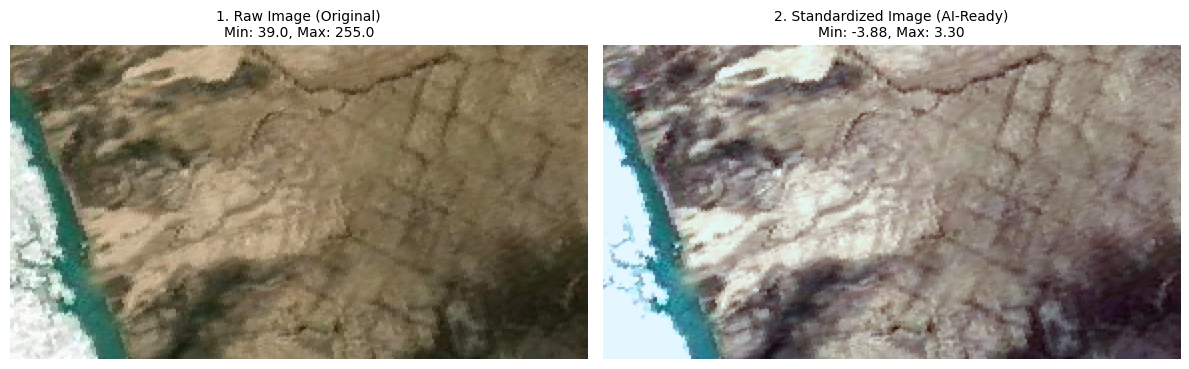

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Define folders
raw_folder = Path("competition_release/train/images")
std_folder = Path("competition_release/train/images_standardized")

# Grab the first file
files = list(std_folder.glob("*.npz"))

if files:
    sample_file = files[0]

    # 2. Print the exact text info
    print(f"Opening: {sample_file.name}\n")

    # Load standardized image details
    with np.load(std_folder / sample_file.name) as data:
        std_img = data["image"]
        print(f"Keys inside the file: {list(data.files)}")
        print(f"Shape (Height, Width, Bands): {std_img.shape}")
        print(f"Data type: {std_img.dtype}")
        print(f"Minimum pixel value: {std_img.min():.6f}")
        print(f"Maximum pixel value: {std_img.max():.6f}")

        # Prepare standardized RGB for visualization
        std_rgb = std_img[..., :3]
        std_vis = (std_rgb - std_rgb.min()) / (std_rgb.max() - std_rgb.min() + 1e-6)

    # 3. Load raw image for comparison visualization
    raw_path = raw_folder / sample_file.name
    if raw_path.exists():
        with np.load(raw_path) as data:
            raw_img = data["image"]
            raw_rgb = raw_img[..., :3]
            raw_min, raw_max = np.nanmin(raw_rgb), np.nanmax(raw_rgb)
            # Handle NaNs and stretch contrast for the raw image
            raw_vis = np.nan_to_num((raw_rgb - raw_min) / (raw_max - raw_min + 1e-6))
    else:
        raw_vis = None

    # 4. Plot both images side by side
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    if raw_vis is not None:
        axes[0].imshow(raw_vis)
        axes[0].set_title(f"1. Raw Image (Original)\nMin: {raw_min:.1f}, Max: {raw_max:.1f}", fontsize=10)
        axes[0].axis("off")

    axes[1].imshow(std_vis)
    axes[1].set_title(f"2. Standardized Image (AI-Ready)\nMin: {std_img.min():.2f}, Max: {std_img.max():.2f}", fontsize=10)
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No .npz files found!")